In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Latihan 1**

In [27]:
import pandas as pd

data = {
    "temperatur": [10, 25, 15, 20, 18, 20, 22, 24],
    "angin":      [0, 0, 5, 3, 7, 10, 5, 6],
    "label":      ["Dingin", "Panas", "Dingin", "Panas", "Dingin", "Dingin", "Panas", "Panas"]
}

df1 = pd.DataFrame(data)
df1

,temperatur,angin,label
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = df1[["temperatur", "angin"]]
y = df1["label"]

## Mencari nilai K terbaik untuk digunakan saat prediksi

In [29]:
best_k = 1
best_acc = 0

for k in range(1, 8):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    pred = model.predict(X)
    acc = accuracy_score(y, pred)

    print(f"k = {k} | akurasi = {acc:.2f}")

    if acc > best_acc:
        best_acc = acc
        best_k = k

print("\nNilai k terbaik:", best_k)

k = 1 | akurasi = 1.00
k = 2 | akurasi = 1.00
k = 3 | akurasi = 1.00
k = 4 | akurasi = 1.00
k = 5 | akurasi = 0.88
k = 6 | akurasi = 1.00
k = 7 | akurasi = 0.75

Nilai k terbaik: 1


In [30]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X, y)

test_df = pd.DataFrame({"temperatur":[16], "angin":[3]})
prediksi = model.predict(test_df)

print("Persepsi Marry untuk kondisi (16°C, 3 km/jam):", prediksi[0])

Persepsi Marry untuk kondisi (16°C, 3 km/jam): Dingin


# **Latihan 2**

In [32]:
# Buat dataset langsung dari tabel soal
data2 = {
    "NIM": ["TI001","TI002","TI003","TI004","TI005","TI006","TI007","TI008","TI009","TI010"],
    "Hasil_Sebenarnya": ["Lulus","Lulus","Lulus","Lulus","Lulus","Tidak Lulus",
                         "Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"],
    "Hasil_Prediksi": ["Lulus","Lulus","Lulus","Tidak Lulus","Tidak Lulus","Lulus",
                       "Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]
}

df2 = pd.DataFrame(data2)
df2

,NIM,Hasil_Sebenarnya,Hasil_Prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


[[3 2]
 [1 4]]


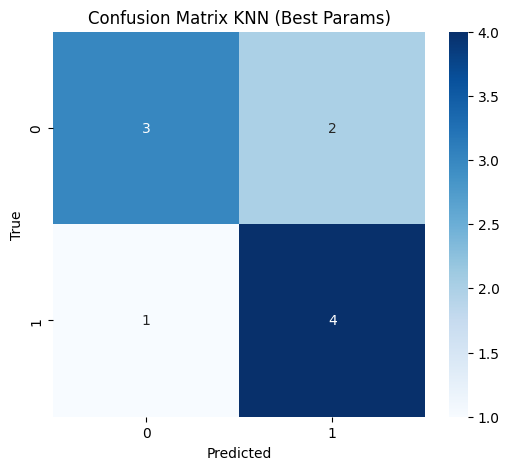

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = df2["Hasil_Sebenarnya"]
y_pred = df2["Hasil_Prediksi"]

labels = ["Lulus", "Tidak Lulus"]
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")

print(cm)
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, classification_report

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

       Lulus       0.75      0.60      0.67         5
 Tidak Lulus       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



# **Latihan 3**

In [9]:
df_cuaca = pd.read_csv('/content/drive/MyDrive/ML/Tugas/Tugas10/data/weather_classification_data.csv')
df_cuaca.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [10]:
df_cuaca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [11]:
categorical_cols = df_cuaca.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"--- Kolom kategorikal: {col} ---")
    print("Jumlah nilai unik:", df_cuaca[col].nunique())
    print("Daftar nilai unik:", df_cuaca[col].unique())
    print("\n")

--- Kolom kategorikal: Cloud Cover ---
Jumlah nilai unik: 4
Daftar nilai unik: ['partly cloudy' 'clear' 'overcast' 'cloudy']


--- Kolom kategorikal: Season ---
Jumlah nilai unik: 4
Daftar nilai unik: ['Winter' 'Spring' 'Summer' 'Autumn']


--- Kolom kategorikal: Location ---
Jumlah nilai unik: 3
Daftar nilai unik: ['inland' 'mountain' 'coastal']


--- Kolom kategorikal: Weather Type ---
Jumlah nilai unik: 4
Daftar nilai unik: ['Rainy' 'Cloudy' 'Sunny' 'Snowy']




In [12]:
from os import replace
replacements = {
    "Cloud Cover": {
        "clear": 0,
        "partly cloudy": 1,
        "overcast": 2,
        "cloudy": 3
    },
    "Season": {
        "Winter": 0,
        "Spring": 1,
        "Summer": 2,
        "Autumn": 3
    },
    "Location": {
        "inland": 0,
        "mountain": 1,
        "coastal": 2
    },
    "Weather Type": {
        "Sunny": 0,
        "Cloudy": 1,
        "Rainy": 2,
        "Snowy": 3
    }
}

df_cuaca = df_cuaca.replace(replacements, inplace=False)
df_cuaca.head()

/tmp/ipython-input-2271175889.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cuaca = df_cuaca.replace(replacements, inplace=False)


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,1,1010.82,2,0,3.5,0,2
1,39.0,96,8.5,71.0,1,1011.43,7,1,10.0,0,1
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,1,0
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,2,0
4,27.0,74,17.0,66.0,2,990.67,1,0,2.5,1,2


In [13]:
df_cuaca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  int64  
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  int64  
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  int64  
 10  Weather Type          13200 non-null  int64  
dtypes: float64(5), int64(6)
memory usage: 1.1 MB


In [14]:
df_cuaca.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


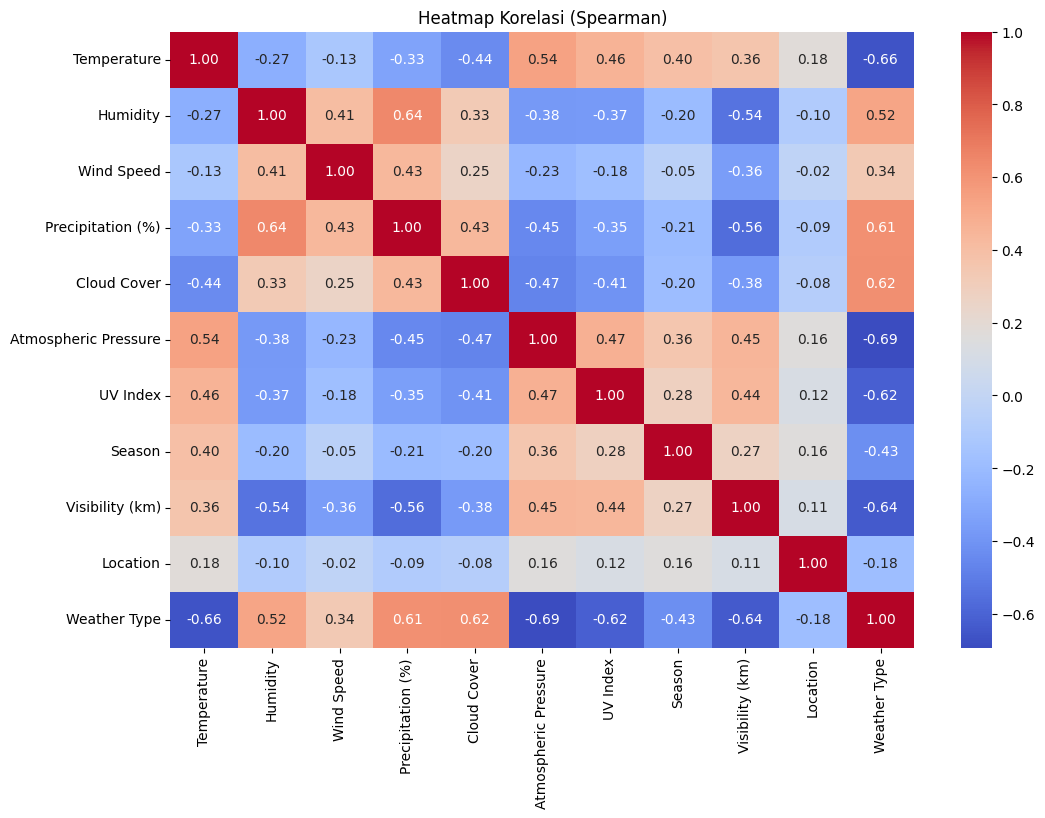

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung matriks korelasi menggunakan Spearman
correlation_matrix = df_cuaca.corr(method='spearman')
# Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

In [16]:
df_cuaca['Weather Type'].value_counts()

,count
Weather Type,
2,3300
1,3300
0,3300
3,3300


/tmp/ipython-input-2567194105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df_cuaca, palette='Set2')


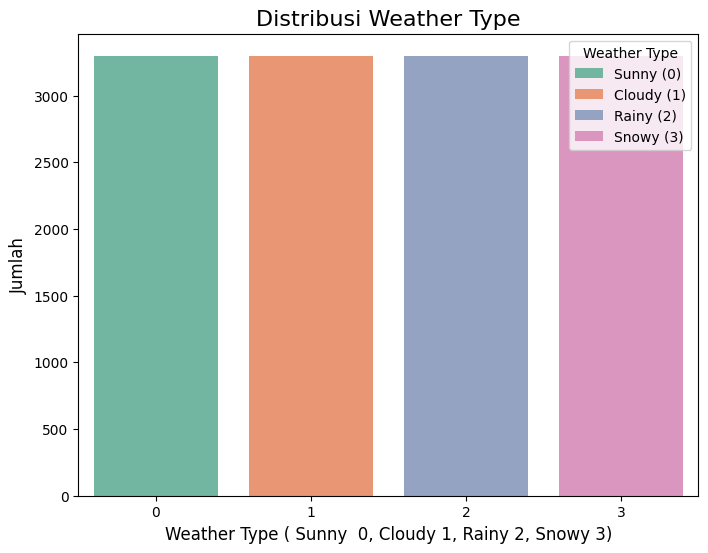

In [17]:
#Membuat diagram batang untuk status kelulusan
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=df_cuaca, palette='Set2')

#Menambahkan judul dan label
plt.title('Distribusi Weather Type', fontsize = 16)
plt.xlabel('Weather Type ( Sunny  0, Cloudy 1, Rainy 2, Snowy 3)', fontsize = 12)
plt.ylabel('Jumlah', fontsize=12)

#Menambahkan legend (adjusted labels for correctness)
plt.legend(title='Weather Type', labels=['Sunny (0)', 'Cloudy (1)', 'Rainy (2)', 'Snowy (3)'], loc='upper right')

#Menampilkan plot
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_cuaca.drop(columns=["Weather Type"])
y = df_cuaca["Weather Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [19]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

sm = SMOTE (random_state=42, k_neighbors=1) # Set k_neighbors to 1
x_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Weather Type
2    2640
3    2640
1    2640
0    2640
Name: count, dtype: int64
After SMOTE:
Weather Type
2    2640
3    2640
1    2640
0    2640
Name: count, dtype: int64


In [20]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': list(range (1, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV (KNeighborsClassifier(), param_grid, cv = 3, n_jobs=-1)
grid.fit(x_train_smote, y_train_smote)

print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best Score (CV): 0.8993371212121213


In [21]:
best_knn = grid.best_estimator_
best_knn.fit(x_train_smote, y_train_smote)

# Prediksi
y_pred = best_knn.predict(X_test_scaled)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       660
           1       0.87      0.88      0.87       660
           2       0.87      0.89      0.88       660
           3       0.92      0.92      0.92       660

    accuracy                           0.89      2640
   macro avg       0.90      0.89      0.89      2640
weighted avg       0.90      0.89      0.89      2640



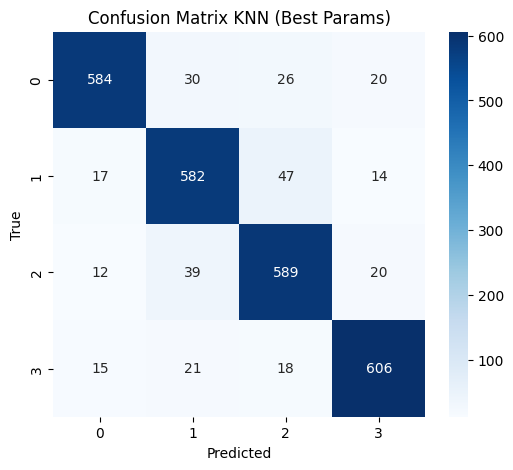

In [23]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_knn, x_train_smote, y_train_smote, cv = 5 )
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.8993371212121213
Std Dev: 0.008876294057159465


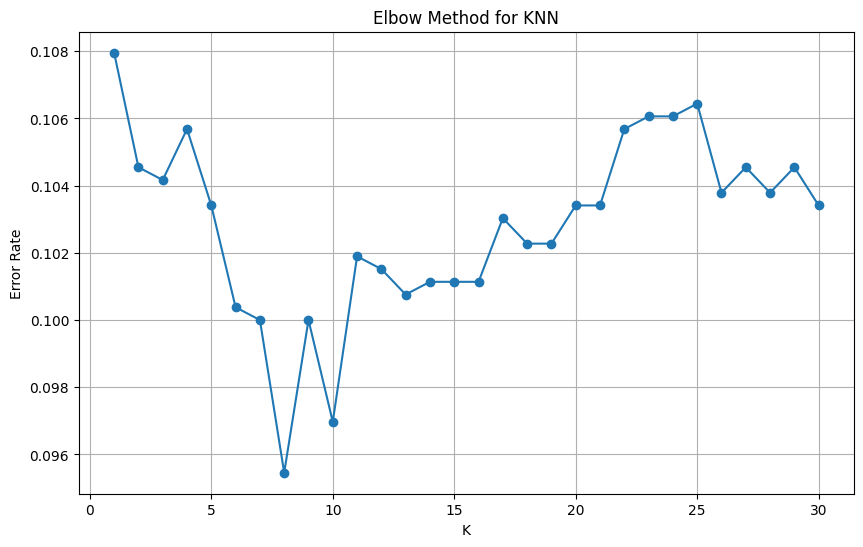

In [26]:
errors = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_smote, y_train_smote)
    pred = knn_temp.predict(X_test_scaled)
    errors.append(np.mean(pred != y_test))
plt.figure(figsize = (10, 6))
plt.plot(range(1,31), errors, marker='o')
plt.title("Elbow Method for KNN")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()